# Summary budget plot

Plot one figure with three pannels providing an overview of the budget without too much details.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

In [2]:
b1 = '../../data/knmi/slbudget_2026_08_12_ZSM_tide_gauge_1960_2025_ERA5_StericEN4_22_[500, 4000]m.csv'

budget_df = pd.read_csv(b1)
budget_df.set_index('time', inplace=True)

In [3]:
budget_df

,Total,RegSteric,GloSteric,GIA,Glaciers,Antarctica,Greenland,TWS,Nodal,Wind,Pressure,Obs
time,,,,,,,,,,,,
1960,1.330705,-1.541471,1.172172,0.736667,1.192500,0.095833,0.115833,-0.508333,-0.052226,-2.170257,2.289987,0.889984
1961,5.242993,-1.491322,1.359791,0.773500,1.235000,0.101667,0.124167,-0.360000,-0.016606,2.857125,0.659672,7.656651
1962,3.536294,-2.773234,1.488711,0.810333,1.287500,0.105833,0.133333,-0.424167,0.076486,2.741321,0.090176,2.406651
1963,-2.557647,-3.986956,1.355248,0.847167,1.316667,0.111667,0.135000,-0.519167,0.216538,-2.616677,0.582866,-3.326683
1964,-1.558583,-1.368845,1.121032,0.884000,1.312500,0.115833,0.135833,-0.673333,0.387736,-2.333129,-1.140210,-1.276683
...,...,...,...,...,...,...,...,...,...,...,...,...
2021,15.739985,2.761801,5.688242,2.983500,3.481091,1.113667,0.368375,-0.981076,0.601550,-0.244077,-0.033088,15.723317
2022,18.146147,3.813890,5.814225,3.020333,3.529803,1.056188,0.372135,-0.979197,0.772196,1.297772,-0.551198,17.006651
2023,23.460284,5.529121,5.940207,3.057167,3.578515,1.041644,0.378246,-0.977318,0.911247,2.698000,1.303455,22.823317


In [4]:
def plot_budget_summary(slmean_df, language):
    '''Plot time series of contributors.
    Language can be 'en' or 'nl' '''

    df = slmean_df.copy()
    df2 = slmean_df.copy()
    
    # Combined contributors plot:
    df['Steric'] = df['RegSteric'] + df['GloSteric']
    df['IceSheets'] = df['Glaciers'] + df['Antarctica'] + df['Greenland']
    df['WindPressure'] = df['Wind'] + df['Pressure']
    # Columns to plot (aggregated)
    contributors_agg = ['Steric', 'GIA', 'IceSheets', 'TWS', 'Nodal', 'WindPressure']
    
    # Legend
    if language == 'en':
        legend_labels = {
            'Steric': 'Regional steric',
            'IceSheets': 'Antarctica, Greenland and glaciers',
            'WindPressure': 'Wind + Pressure',
            'GIA': 'GIA',
            'TWS': 'Terrestrial water storage',
            'Nodal': 'Nodal',
            'Total': 'Total',
            'Obs': 'Observations'
        }
        axbig_xlabel = 'Time [year]'
        axbig_ylabel = f'Sea level contribution relative to {df.index[0]} [cm]'
        ax10_title = 'Linear trend budget'
        ax10_ylabel = 'Linear trend [mm/year]'
        ax10_text1 = 'Observed trend'
        ax10_text2 = 'Budget trend'
        ax11_title = 'Acceleration budget'
        ax11_ylabel = 'Acceleration [$10^{-2} mm/year^2$]'
        ax11_text1 = 'Observed acceleration'
        ax11_text2 = 'Budget acceleration'
        
    elif language == 'nl':
        legend_labels = {
            'Steric': 'Regionaal sterisch',
            'IceSheets': 'Antarctica, Groenland en gletsjers',
            'WindPressure': 'Wind + Luchtdruk',
            'GIA': 'GIA',
            'TWS': 'Landoppervlaktewateropslag',
            'Nodal': 'Nodaal',
            'Total': 'Totaal',
            'Obs': 'Waarnemingen'  # or 'Observaties'
        }
        axbig_xlabel = 'Tijd [jaar]'
        axbig_ylabel = f'Zeespiegelbijdrage t.o.v. {df.index[0]} [cm]'
        ax10_title = 'Lineaire trend budget'
        ax10_ylabel = 'Lineaire trend [mm/jaar]'
        ax10_text1 = 'Waargenomen trend'
        ax10_text2 = 'Budgettrend'
        ax11_title = 'Versnellingsbudget'
        ax11_ylabel = 'Versnelling [$10^{-2} mm/jaar^2$]'
        ax11_text1 = 'Waargenomen versnelling'
        ax11_text2 = 'Budgetversnelling'

        df2.columns = ['Totaal', 'RegSterisch', 'GloSterisch', 'GIA', 
                       'Gletsjers', 'Antarctica', 'Groenland', 'LOW', 
                       'Nodaal', 'Wind', 'Luchtdruk', 'Waarnemingen']
        
    else:
        print('Language not supported')
    
    # Color scheme
    colors_agg = ['blue', 'green', 'magenta', 'orange', 'black', 'cyan']

    # Font sizes
    label_size = 13
    legend_size = 12
    ticklabel_size = 12
    
    # Figure 
    fig, axs = plt.subplots(ncols=2, nrows=2, figsize=(10,10))
    gs = axs[0, 0].get_gridspec()
    # remove the underlying Axes
    for ax in axs[0, :]:
        ax.remove()
    axbig = fig.add_subplot(gs[0, :])

    for col, color in zip(contributors_agg, colors_agg):
        axbig.plot(df[col] - df[col].iloc[0], color=color, label=legend_labels[col])
    axbig.plot(df['Total'] - df['Total'].iloc[0], color='red', label=legend_labels['Total'])
    axbig.plot(df['Obs'] - df['Obs'].iloc[0], 'o-', label=legend_labels['Obs'])
    axbig.set_xlabel(axbig_xlabel, fontsize=label_size)
    axbig.set_ylabel(axbig_ylabel, fontsize=label_size)
    axbig.grid(True)
    axbig.legend(loc='upper left', fontsize=legend_size)
    
    # Increase tick label size
    axbig.tick_params(axis='both', which='major', labelsize=ticklabel_size)

    ### Plot the trend and acceleration budget
    lin_trend = np.polyfit(df2.index, 
                           df2 * 10, 1)[0,:]  # Convert from cm to mm

    acceleration = 2 * np.polyfit(df2.index, df2 * 10, 2)[0,:]
    # Convert from mm^2 / year to 10^-2 mm^2 / year
    acceleration = acceleration * 100 
    
    if 'Steric' in df2.columns:
        colors = ['red', 'blue', 'green', 'brown', 'magenta', 'grey', 'orange', 
                  'black', 'cyan', 'yellow']
            
    else:  
        colors = ['red', 'blue', 'purple', 'green', 'brown', 'magenta', 'grey', 
                  'orange', 'black', 'cyan', 'olive']

    ind = np.arange(len(df2.columns) - 1 )

    legend_elements = []
    for i in ind:
        legend_elements.append(Line2D([0], [0], color = colors[i], lw = 4, 
                                      label = df2.columns[i]))

    legend_elements.append(Line2D([0], [0], color = 'black', lw = 2, 
                                  label = df2.columns[-1]))
    axs[1,0].set_title(ax10_title, fontsize=label_size)
    axs[1,0].bar(ind, lin_trend[:-1], color=colors)
    axs[1,0].hlines(y=lin_trend[-1], xmin=-0.5, xmax=0.5, color='black')
    axs[1,0].set_xticks([])
    axs[1,0].tick_params(labelsize=ticklabel_size)
    axs[1,0].set_ylabel(ax10_ylabel, fontsize=label_size)
    axs[1,0].legend(handles=legend_elements, loc='center right', fontsize=legend_size)
    axs[1,0].text(0.4, 0.95, 
                 f'{ax10_text1}: {round(lin_trend[-1],2)}\n'+ 
                 f'{ax10_text2}: {round(lin_trend[0],2)}', 
                 va='top', ha='center', 
                 transform=axs[1,0].transAxes,
                 fontsize=ticklabel_size)

    axs[1,1].set_title(ax11_title, fontsize=label_size)
    axs[1,1].bar(ind, acceleration[:-1], color=colors)
    axs[1,1].hlines(y=acceleration[-1], xmin=-0.5, xmax=0.5, color='black')
    axs[1,1].set_xticks([])
    axs[1,1].tick_params(labelsize=ticklabel_size)
    axs[1,1].set_ylabel(ax11_ylabel, fontsize=label_size) 
    axs[1,1].text(0.98, 0.98, 
                 f'{ax11_text1}: {round(acceleration[-1],2)}\n'+ 
                 f'{ax11_text2}: {round(acceleration[0],2)}', 
                 va='top', ha='right', 
                 transform=axs[1,1].transAxes,
                 fontsize=ticklabel_size)
    
    fig.tight_layout()

    return fig, axs

In [5]:
budget_df.columns

Index(['Total', 'RegSteric', 'GloSteric', 'GIA', 'Glaciers', 'Antarctica',
       'Greenland', 'TWS', 'Nodal', 'Wind', 'Pressure', 'Obs'],
      dtype='str')

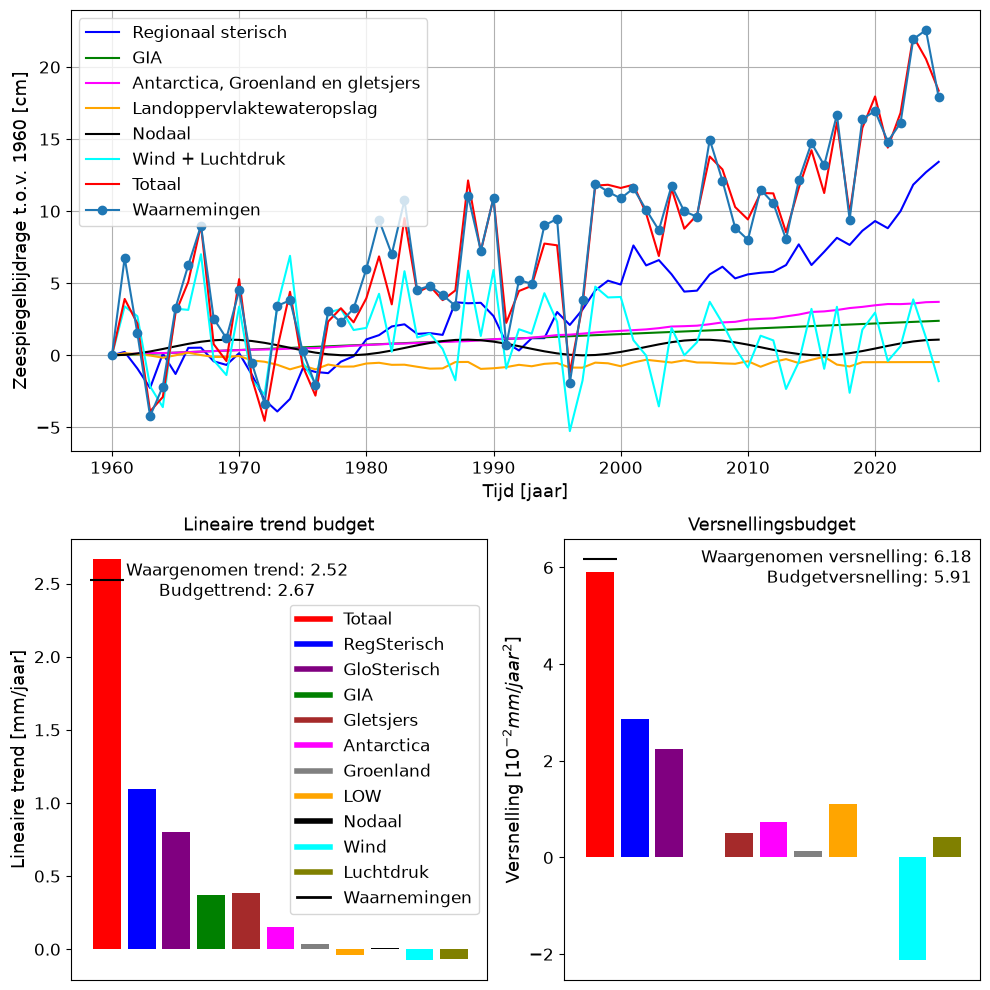

In [6]:
fig, axs = plot_budget_summary(budget_df, 'nl')

In [7]:
fig.savefig('../../rapportage/slm2026/images/budget.png', bbox_inches='tight')